In [18]:
import pandas as pd
df=pd.read_csv("student-mat.csv",delimiter=";")
print (df)


    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health 

In [4]:
colcategoricas = df.select_dtypes(include='object').columns

for column in colcategoricas:
    print(df[column].value_counts() / len(df))


/var/folders/rg/gm2zvlrs4857hptpljtqnz5r0000gn/T/ipykernel_69351/3134933568.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


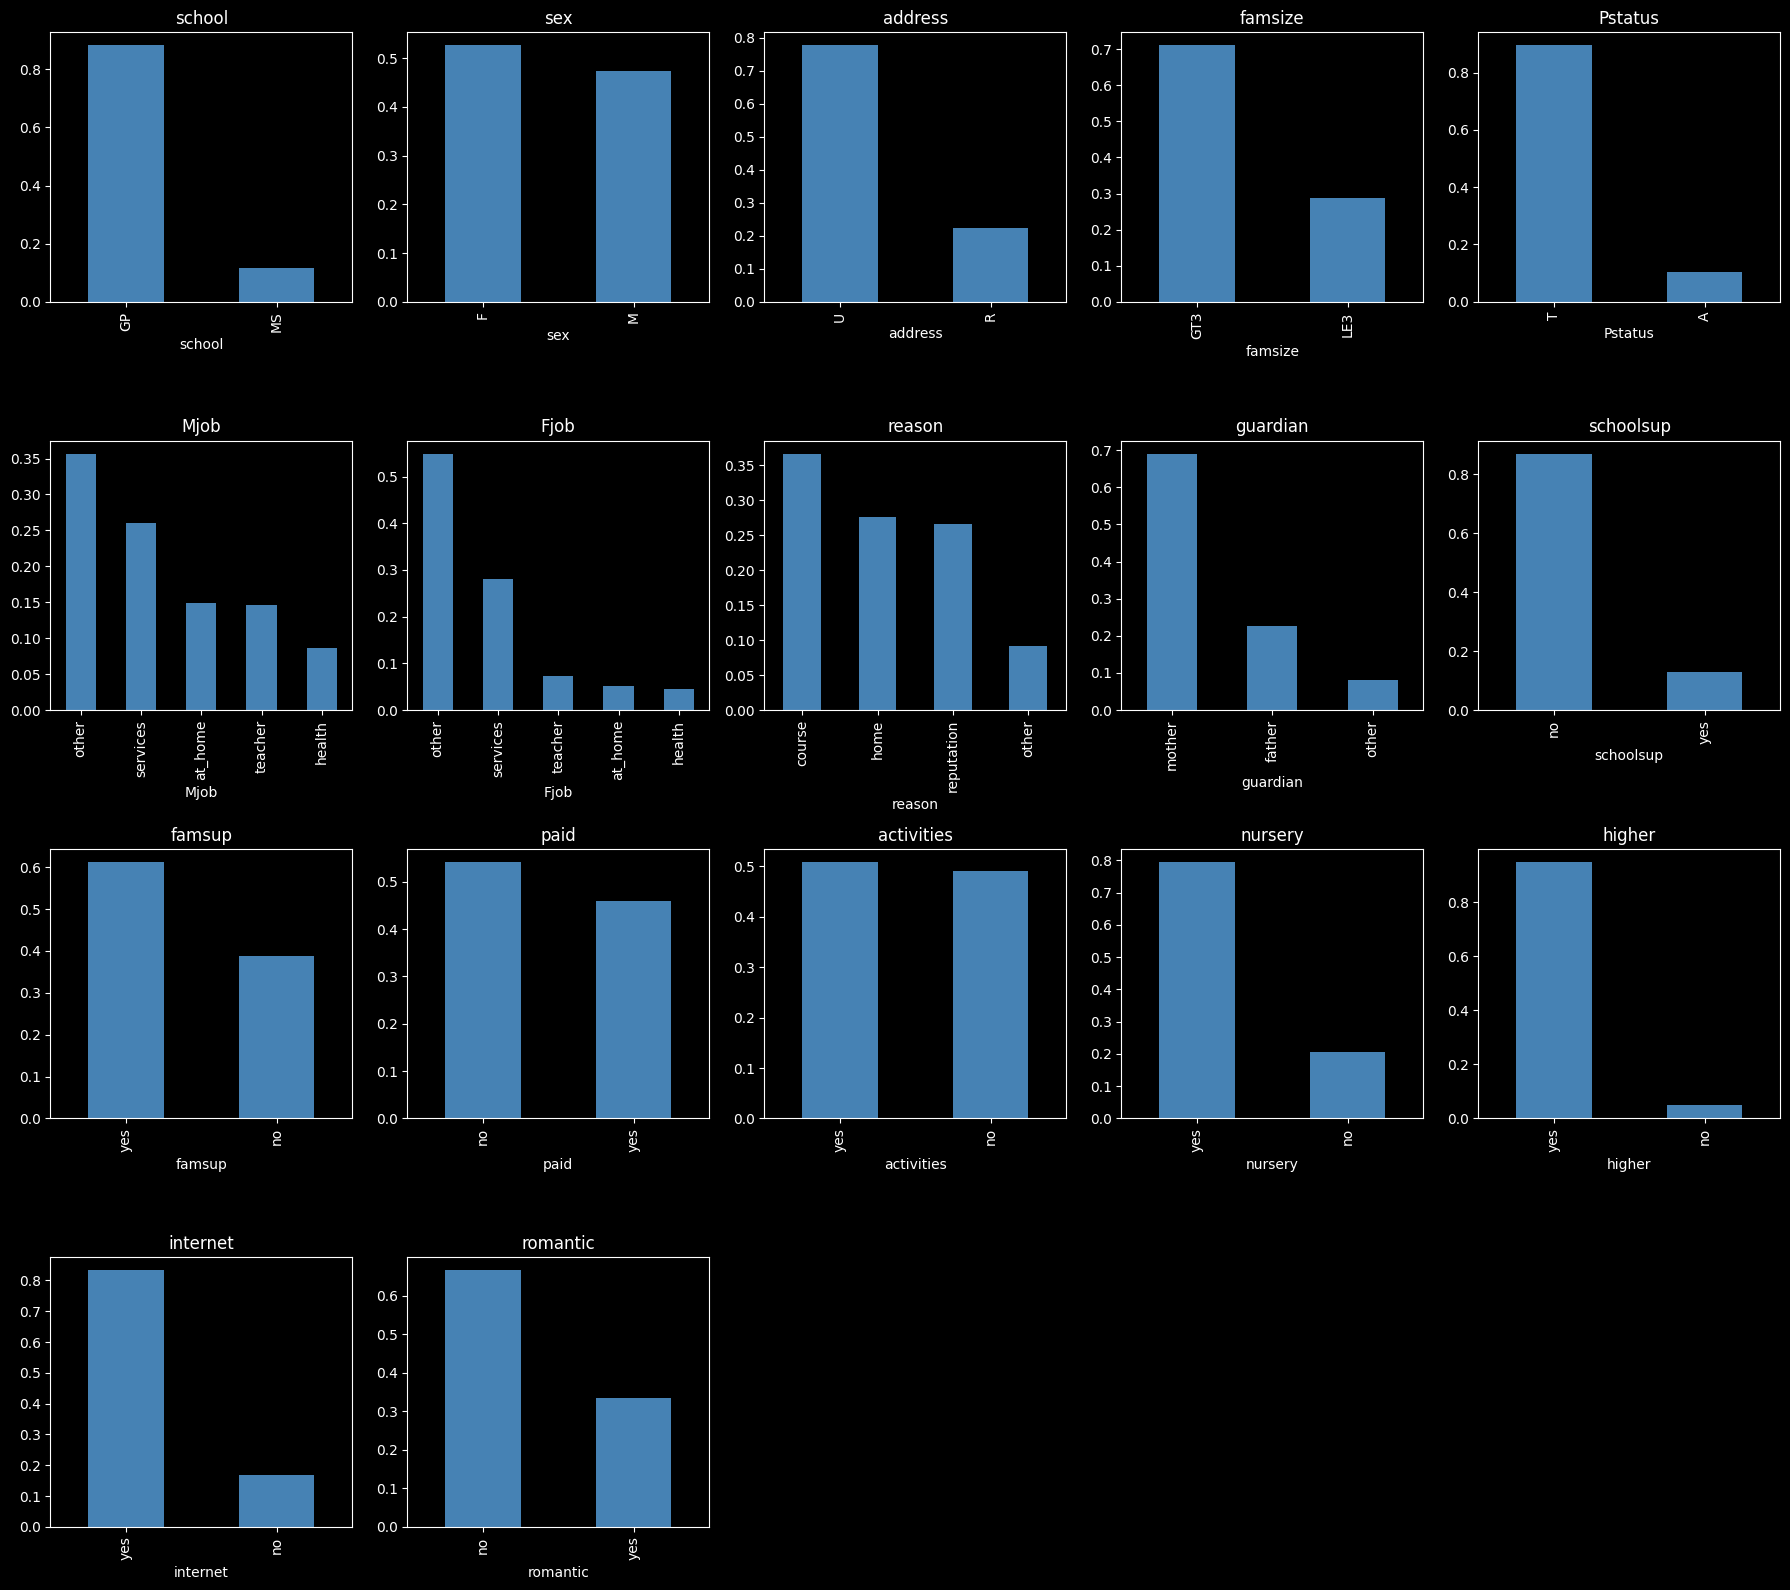

In [55]:
import matplotlib.pyplot as plt

#print(len(cat_cols))

fig, eixo = plt.subplots(4, 5, figsize=(18, 16))

for ex, col in zip(eixo.flatten(), colcategoricas):
    df[col].value_counts(normalize=True).plot(kind='bar', ax=ex, color='steelblue')
    ex.set_title(col)

for ex in eixo.flatten()[len(colcategoricas):]:
    ex.set_visible(False)

plt.tight_layout()
plt.show()


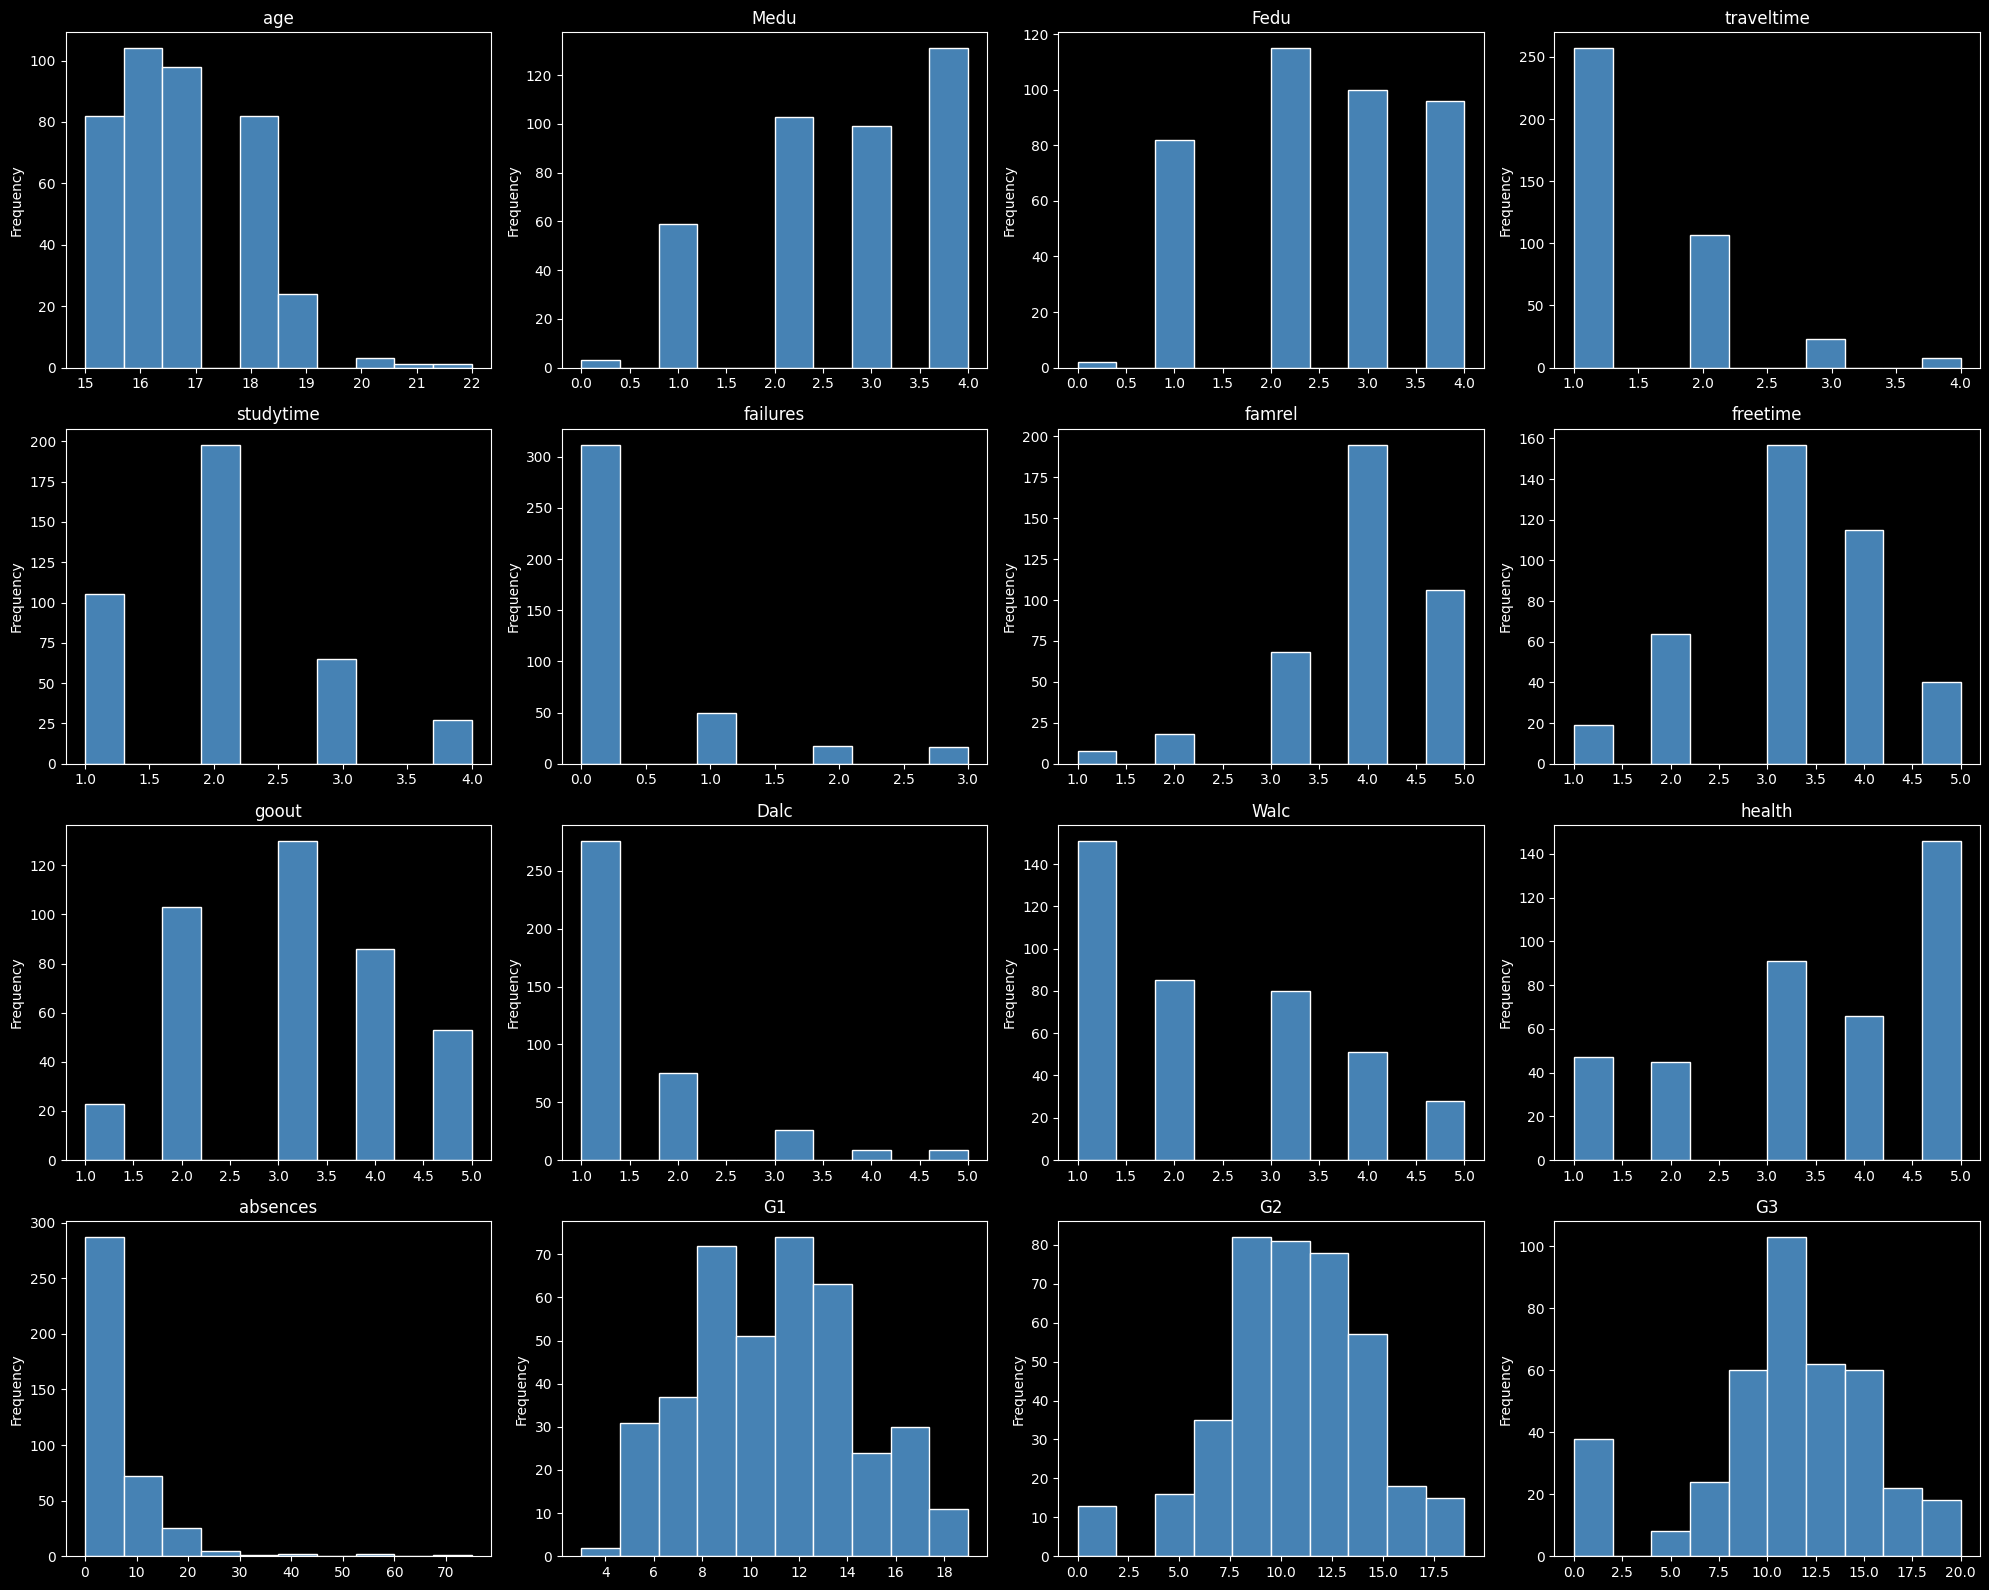

In [58]:
num_cols = df.select_dtypes(include='number').columns

#print(len(num_cols))
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, col in zip(axes.flatten(), num_cols):
    df[col].plot(kind='hist', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)

for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
stats = df.describe().T
stats['skewness'] = df.skew(numeric_only=True)

print(stats[['mean', '50%', 'std', 'min', 'max', 'skewness']]) #só os que queremos

                 mean   50%       std   min   max  skewness
age         16.696203  17.0  1.276043  15.0  22.0  0.466270
Medu         2.749367   3.0  1.094735   0.0   4.0 -0.318381
Fedu         2.521519   2.0  1.088201   0.0   4.0 -0.031672
traveltime   1.448101   1.0  0.697505   1.0   4.0  1.607029
studytime    2.035443   2.0  0.839240   1.0   4.0  0.632142
failures     0.334177   0.0  0.743651   0.0   3.0  2.387026
famrel       3.944304   4.0  0.896659   1.0   5.0 -0.951882
freetime     3.235443   3.0  0.998862   1.0   5.0 -0.163351
goout        3.108861   3.0  1.113278   1.0   5.0  0.116502
Dalc         1.481013   1.0  0.890741   1.0   5.0  2.190762
Walc         2.291139   2.0  1.287897   1.0   5.0  0.611960
health       3.554430   4.0  1.390303   1.0   5.0 -0.494604
absences     5.708861   4.0  8.003096   0.0  75.0  3.671579
G1          10.908861  11.0  3.319195   3.0  19.0  0.240613
G2          10.713924  11.0  3.761505   0.0  19.0 -0.431645
G3          10.415190  11.0  4.581443   

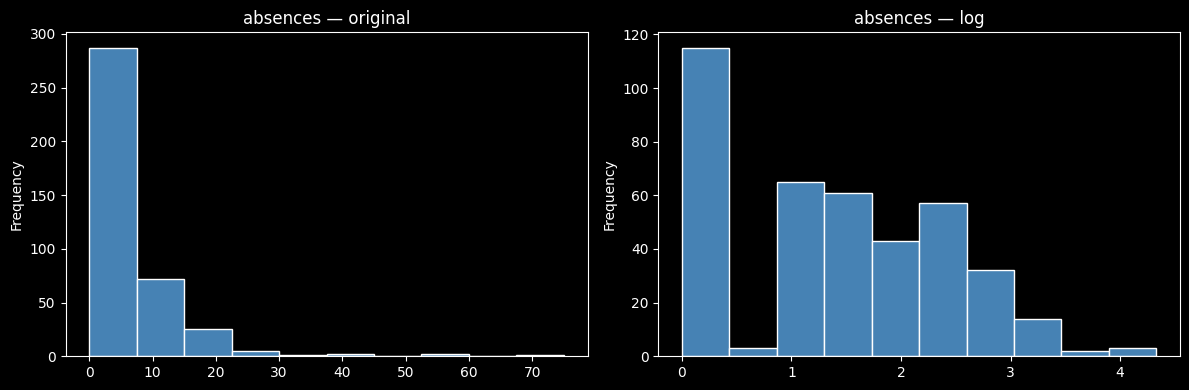

In [43]:
#print(df.skew(numeric_only=True).sort_values(ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['absences'].plot(kind='hist', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('absences — original')

df['absences_log'] = (df['absences']+1).apply('log')
df['absences_log'].plot(kind='hist', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('absences — log')

plt.tight_layout()
plt.show()

In [44]:
df['age_group'] = pd.cut(df['age'], bins=[14, 16, 18, 22], labels=['14-16', '17-18', '19-22'])

print(df['age_group'].value_counts())


age_group
14-16    186
17-18    180
19-22     29
Name: count, dtype: int64


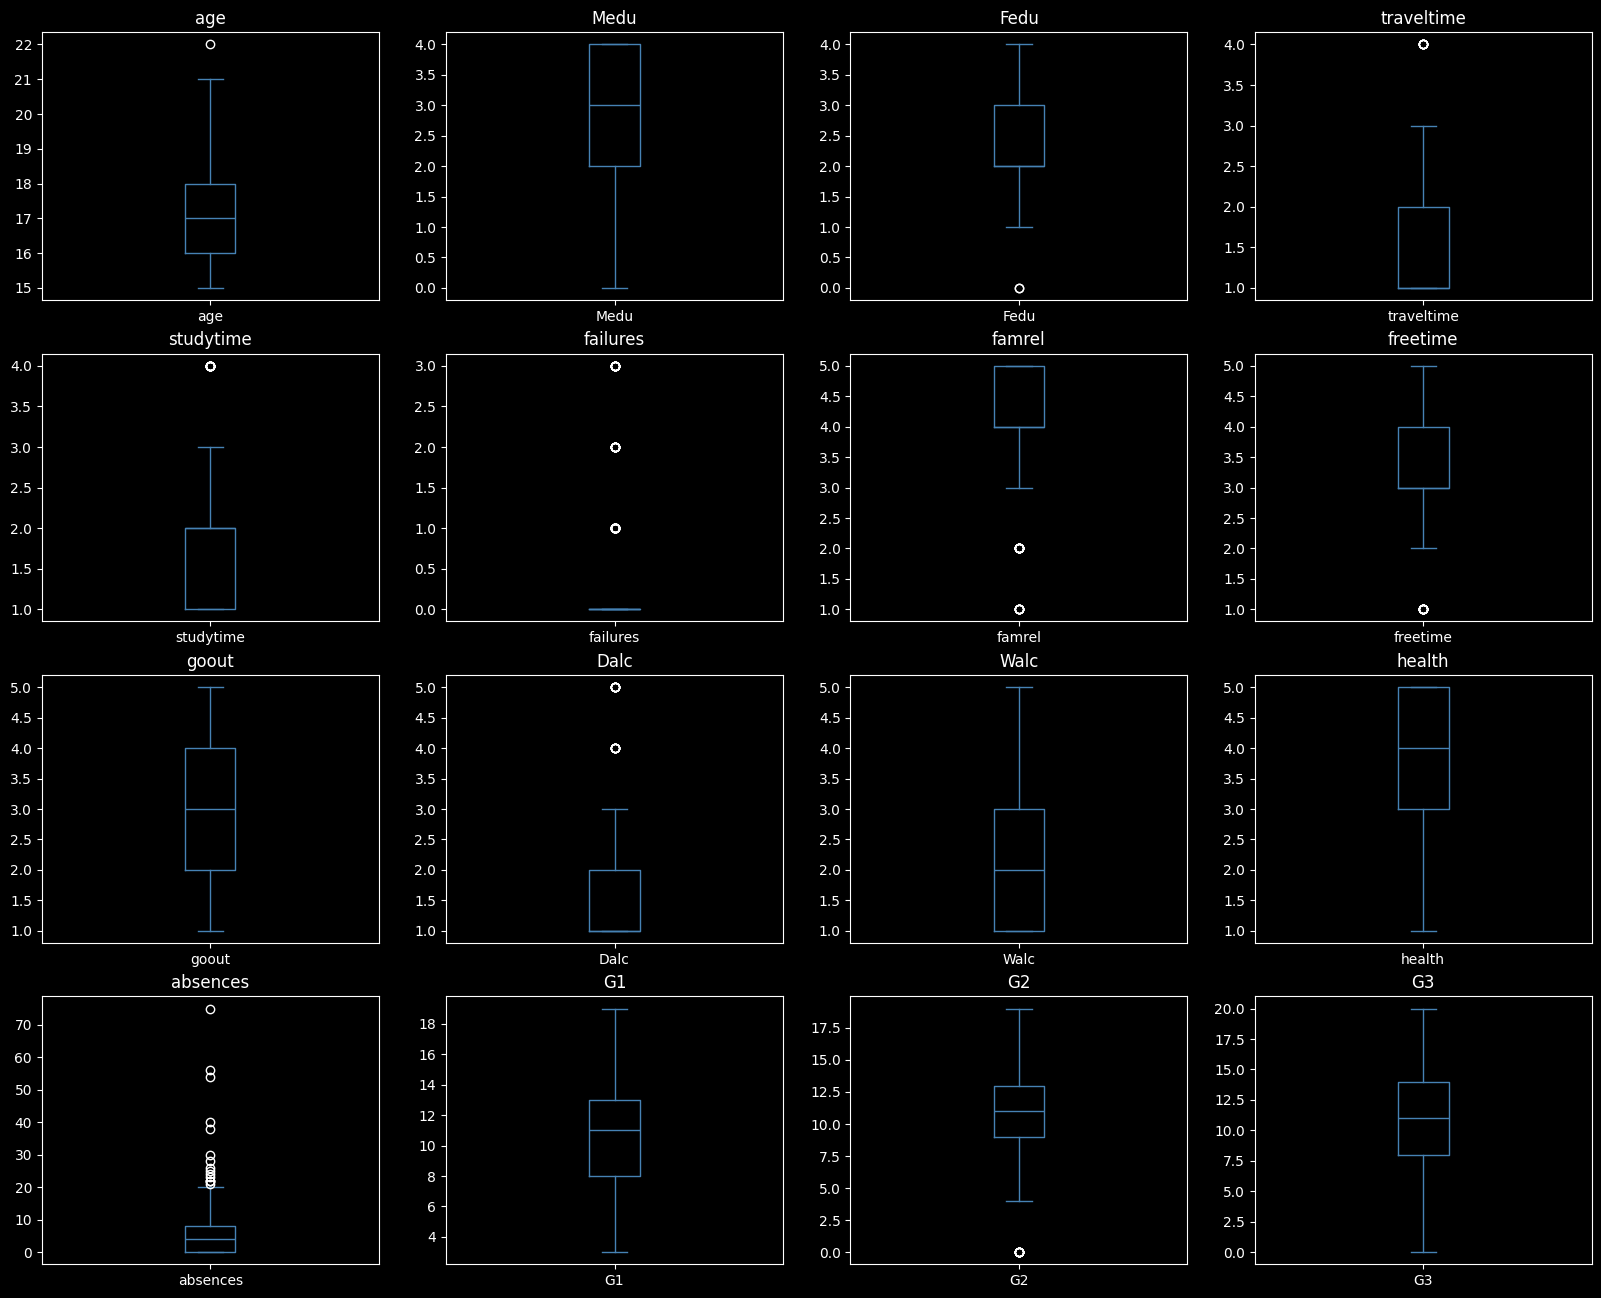

In [49]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, col in zip(axes.flatten(), num_cols):
    df[col].plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(col)

for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)



In [50]:
plt.tight_layout()
plt.show()

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
print(outliers.sum())

age              1
Medu             0
Fedu             2
traveltime       8
studytime       27
failures        83
famrel          26
freetime        19
goout            0
Dalc            18
Walc             0
health           0
absences        15
G1               0
G2              13
G3               0
absences_log     0
dtype: int64


In [66]:
media = df['failures'].mean() #media
dp = df['failures'].std() #desvio padrao
n = len(df['failures']) #nº alunos
ea = dp / n**0.5 #erro absoluto

confi = 1.96 #95% de confiança

ic_lower = media - confi * ea
ic_upper = media + confi * ea #Intervalo confiança- media+- margem de erro

print(f"Média: {media:.2f}")
print(f"Intervalo de confiança (95%): ({ic_lower:.2f}, {ic_upper:.2f})")

Média: 0.33
Intervalo de confiança (95%): (0.26, 0.41)
